## **K-Nearest Neighbors (K-Vizinhos mais Próximos)**
O **KNN** é um algoritmo de **aprendizado supervisionado** usado em problemas de **classificação** e **regressão**.

Considere um conjunto de observações:

$$
\mathcal{D} = \{(\mathbf{x}_i, y_{i})\}_{i=1}^{N}
\quad \text{onde}
\quad \mathbf{x}_i \in \mathbb{R}^{D}
$$

E dependendo do tipo de problema, temos:

#### **Classificação**

O valor de $y_i$ é uma classe:

$$
y_i \in \mathcal{C} = \{c_i\}_{i=1}^{M}, \quad M \leq N
$$

onde $\mathcal{C}$ é o conjunto das classes.

#### **Regressão**

O valor de $y_i$ é um valor real:

$$
y_i \in \mathbb{R}
$$

Dado um novo vetor de atributos $\mathbf{z} \in \mathbb{R}^{D}$, o KNN depende de uma função de distância, $d(.,.)$, definida por:

$$
d : \mathbb{R}^{D} \times \mathbb{R}^{D} \rightarrow \mathbb{R}^{+}
$$


Normalmente, a métrica utilizada é a distância Euclidiana, dada por:

$$
d(\mathbf{z}, \mathbf{x}) = \sqrt{\sum_{j=1}^{D} (z_{j} - x_{j})^{2}}
$$

Calculadas as distâncias de $\mathbf{z}$ e cada $\mathbf{x}_i$, ordenamos o conjunto de dados de acordo com:

$$
d(\mathbf{z}, \mathbf{x}_{(1)}) \leq d(\mathbf{z}, \mathbf{x}_{(2)}) \leq \dots \leq d(\mathbf{z}, \mathbf{x}_{(N)})
$$

Dado um $k \leq N$, definimos então a vizinhança de $\mathbf{z}$:

$$
N_k(\mathbb{z}) := \{(\mathbf{x}_{(1)}, y_{(1)}), (\mathbf{x}_{(2)}, y_{(2)}), \dots, (\mathbf{x}_{(k)}, y_{(k)})\}
$$

são esses os $k$ vizinhos mais próximos.

### **KNN para Regressão**

Sendo $\hat{y} \in \mathbb{R}$, o valor que desejamos predizer, seu valor é dado por:

$$
\hat{y} = \dfrac{1}{k} \cdot \sum_{i=1}^{k} y_{(i)}
$$

onde $y_{(i)} \in N_k(\mathbf{z})$.

### **KNN para Classificação**

Sendo $\hat{y} \in \mathcal{C}$, o valor que desejamos predizer, seu valor é dado por:

$$
\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{i=1}^{k} \mathbb{1}(y_{(i)} = c)
$$

Onde $\mathbb{1}(\cdot)$ é a função indicadora definida como segue:

$$
\mathbb{1}(A) :=
\begin{cases}
1, & \text{se a condição } A \text{ é verdadeira} \\
0, & \text{caso contrário}
\end{cases}
$$

> FACELI, Katti; LORENA, Ana Carolina; GAMA, João; CARVALHO, André C. P. L. F. de. Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina. Rio de Janeiro: LTC, 2011. Cap. 4, p. 58.

## **Implementação do KNN para problema de Classificação**

Vamos utilizar o algoritmo **K-Nearest Neighbors** para tarefa de **classificação**  no dataset [**Iris Flower Dataset**](https://scikit-learn.org/1.5/auto_examples/datasets/plot_iris_dataset.html).

### **Pré-processamento dos dados**

#### **Dataset**

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (150, 4)
Shape de y: (150,)


In [2]:
import pandas as pd

df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


#### **Divisão do dataset nos conjuntos de treino e validação**

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (120, 4)
Teste: (30, 4)


#### **Padronização dos dados (z-score)**

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **Implementação do KNN para Classificação**

In [6]:
import numpy as np
from collections import Counter

def predict_classification(X_train, y_train, z, k):

    distances = []

    for i in range(len(X_train)):
        dist = np.sqrt(np.sum((z - X_train[i]) ** 2))
        distances.append(dist)

    distances = np.array(distances)

    neighbor_idx = np.argsort(distances)[:k]

    neighbor_labels = y_train[neighbor_idx]

    most_common = Counter(neighbor_labels).most_common(1)

    return most_common[0][0]

### **Treinamento e Validação**

#### **Validação**

O **KNN** é  *lazy learning*, então não há treinamento explícito. Segue-se para a validação, onde o desempenho do modelo é avaliado.

In [7]:
def knn_predict(X_train, y_train, X_test, k):

    predictions = []

    for z in X_test:
        pred = predict_classification(X_train, y_train, z, k)
        predictions.append(pred)

    return np.array(predictions)

k = 3
y_pred = knn_predict(X_train, y_train, X_test, k)

#### **Matriz de confusão**

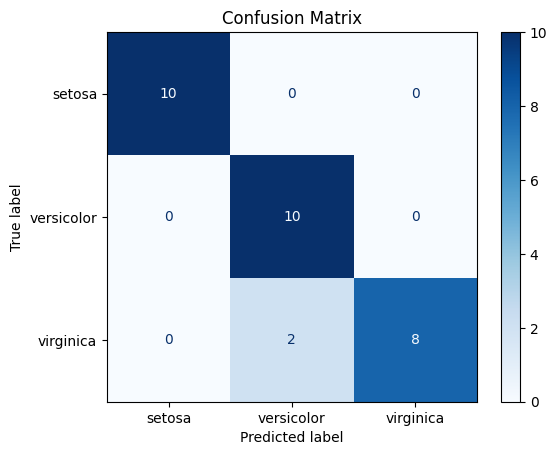

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")

plt.show()

#### **Métricas**

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



#### **Visualização dos dados com PCA**

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train)

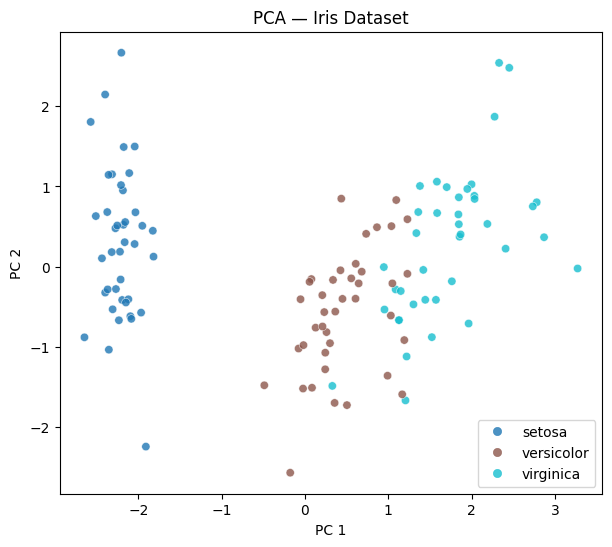

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                     cmap="tab10", edgecolors="white", linewidths=0.4, alpha=0.8)

handles, _ = scatter.legend_elements()
ax.legend(handles, iris.target_names)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("PCA — Iris Dataset")

plt.show()